# 📊 فاز ۱ | تحلیل اکتشافی داده‌ها (EDA)

## 1) توصیف کلی دیتاست
- تعداد رکوردها: **545**
- تعداد ویژگی‌ها: **13**
- هدف: پیش‌بینی **price**
- ویژگی‌های عددی: `price, area, bedrooms, bathrooms, stories, parking`
- ویژگی‌های دسته‌ای: `mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea, furnishingstatus`

---

## 2) آمار توصیفی
**نکات کلیدی:**
- قیمت‌ها بازه‌ای از **{min_price} تا {max_price}** دارند و میانگین قیمت حدود **{mean_price}** است.
- متغیر `area` بیشترین تنوع را دارد و به احتمال زیاد اثرگذارترین متغیر عددی است.
- متغیر `parking` به‌صورت عددی ولی گسسته است (0،1،2،3).

**برداشت کلی:**  
آمار توصیفی نشان می‌دهد داده‌ها برای مدل‌سازی رگرسیون مناسب‌اند و دامنهٔ ویژگی‌ها منطقی است.

---

## 3) توزیع قیمت (Histogram + KDE)
**مشاهده:**  
توزیع قیمت **{skewness}** است. تمرکز اصلی قیمت‌ها در بازهٔ **{price_cluster_range}** قرار دارد.

**تفسیر:**  
- اگر توزیع **راست‌چوله** باشد، می‌توان از تبدیل لگاریتمی روی `price` برای بهبود مدل استفاده کرد.
- وجود دم بلند نشان‌دهنده قیمت‌های خیلی بالا (outliers) است.

---

## 4) Boxplot قیمت
**مشاهده:**  
در باکس‌پلات، تعدادی **نقطه دورافتاده (outlier)** مشاهده می‌شود.

**تفسیر:**  
این outlierها ممکن است خانه‌های لوکس باشند.  
در مدل‌های خطی می‌توان آن‌ها را بررسی کرد ولی در مدل‌های درختی معمولاً مشکل زیادی ایجاد نمی‌کنند.

---

## 5) همبستگی ویژگی‌های عددی
**مشاهده (Heatmap):**
- بیشترین همبستگی با قیمت: **{top_corr_feature} = {top_corr_value}**
- همبستگی‌های متوسط: **{mid_corr_features}**

**تفسیر:**  
ویژگی `area` معمولاً قوی‌ترین رابطه را با قیمت دارد و می‌تواند ستون اصلی مدل‌سازی باشد.  
همبستگی سایر ویژگی‌ها به ما دید خوبی از قدرت توضیح‌دهندگی آن‌ها می‌دهد.

---

## 6) تاثیر ویژگی‌های دسته‌ای بر قیمت (Boxplot)
### mainroad
- خانه‌های در کنار جاده اصلی معمولاً قیمت بالاتری دارند.

### airconditioning
- وجود AC معمولاً باعث افزایش قیمت می‌شود.

### furnishingstatus
- **furnished** معمولاً قیمت بالاتری نسبت به **semi-furnished** و **unfurnished** دارد.

### guestroom / basement / hotwaterheating / prefarea
- این امکانات اغلب اثر مثبت بر قیمت نشان می‌دهند.

**جمع‌بندی:**  
ویژگی‌های دسته‌ای نقش مهمی در قیمت دارند و باید در مدل‌سازی (با One-Hot Encoding) لحاظ شوند.

---

## 7) میانگین قیمت در دسته‌ها (Grouped Means)
**مشاهده:**  
میانگین قیمت برای دسته‌های زیر بالاتر است:
- `furnishingstatus = furnished`
- `airconditioning = yes`
- `prefarea = yes`

**تفسیر:**  
نتایج grouped mean نشان می‌دهد که امکانات و موقعیت‌های خاص مستقیماً با قیمت بالاتر مرتبط هستند.

---

## ✅ جمع‌بندی نهایی فاز ۱
- داده ساختار مناسبی برای رگرسیون دارد.
- `area` مهم‌ترین متغیر عددی است.
- امکاناتی مثل **AC، مبلمان کامل، prefarea** اثر مثبت قابل‌توجه دارند.
- توزیع قیمت احتمالاً راست‌چوله است و تبدیل لگاریتمی ممکن است مفید باشد.


In [2]:
from pathlib import Path
import pandas as pd

ROOT = Path().resolve().parent   # یک پوشه بالاتر از notebooks
data_path = ROOT / "data" / "raw" / "Housing.csv"
save_dir = ROOT / "reports" / "figures"
save_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)


In [3]:
import os
import matplotlib.pyplot as plt

save_dir = ROOT / "reports" / "figures"
os.makedirs(save_dir, exist_ok=True)

plt.tight_layout()
plt.show()  # یا plt.close()


<Figure size 1000x600 with 0 Axes>

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

--- DESCRIBE (Numeric) ---


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000



--- Missing Values ---


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

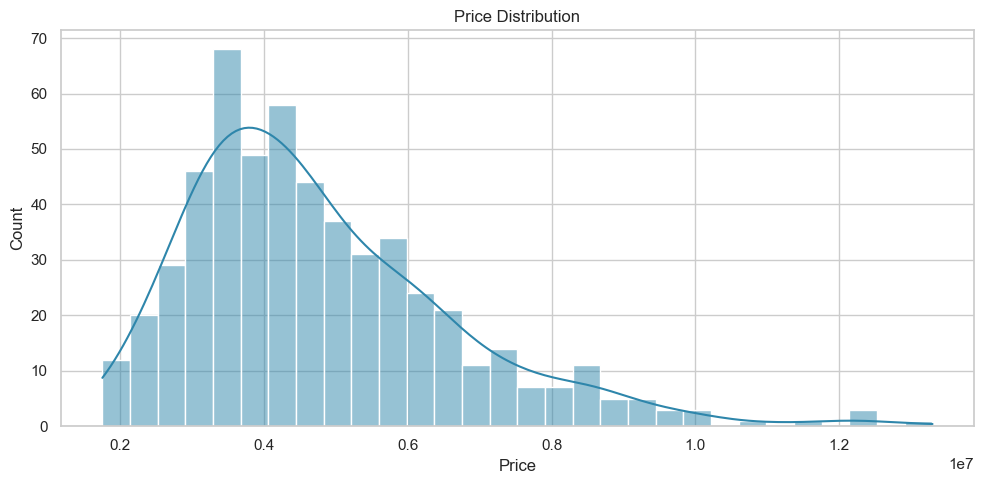

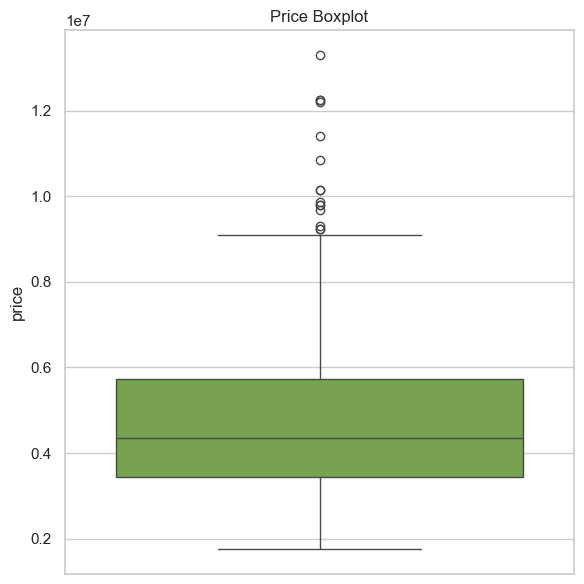

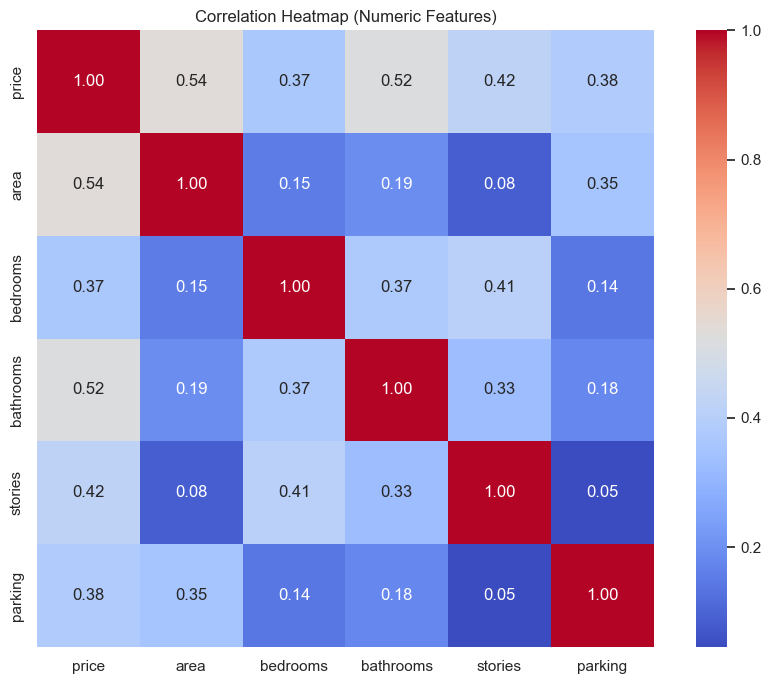

C:\Users\SadidGostaran.Co\AppData\Local\Temp\ipykernel_17556\1147570485.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="price", data=df, palette="Set2")


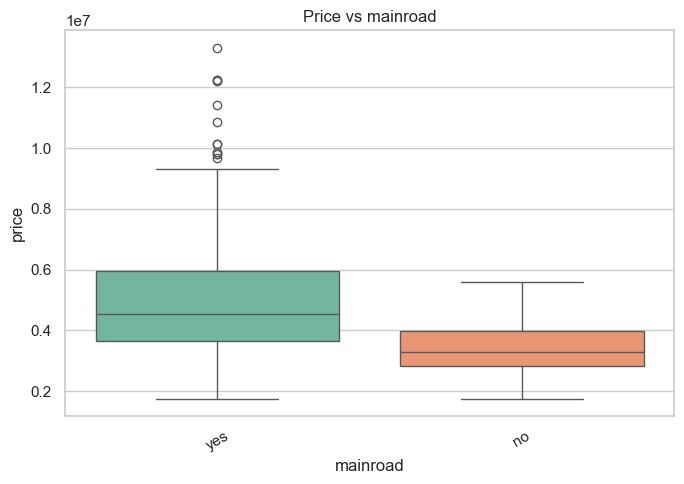

C:\Users\SadidGostaran.Co\AppData\Local\Temp\ipykernel_17556\1147570485.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="price", data=df, palette="Set2")


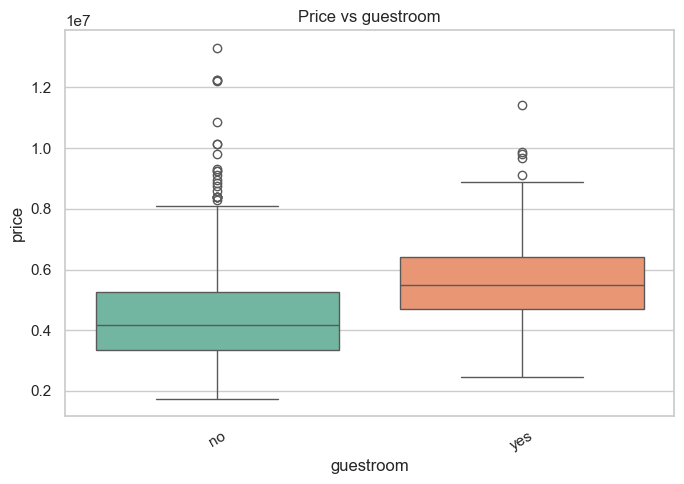

C:\Users\SadidGostaran.Co\AppData\Local\Temp\ipykernel_17556\1147570485.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="price", data=df, palette="Set2")


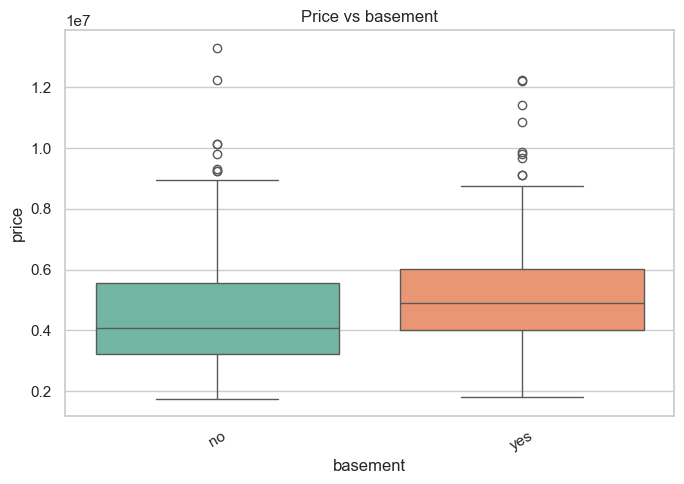

C:\Users\SadidGostaran.Co\AppData\Local\Temp\ipykernel_17556\1147570485.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="price", data=df, palette="Set2")


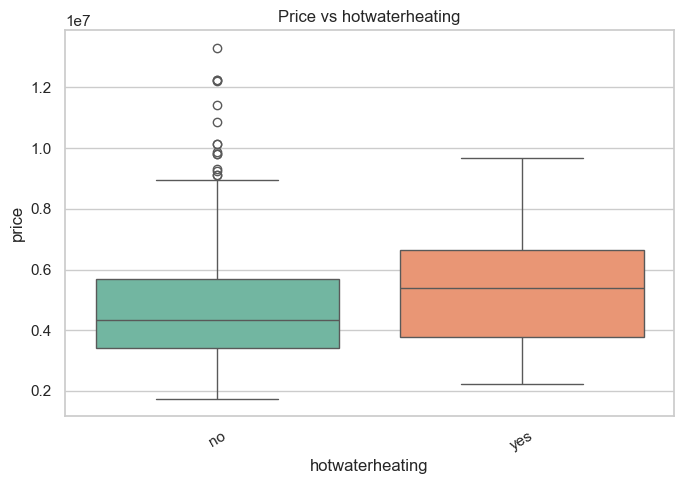

C:\Users\SadidGostaran.Co\AppData\Local\Temp\ipykernel_17556\1147570485.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="price", data=df, palette="Set2")


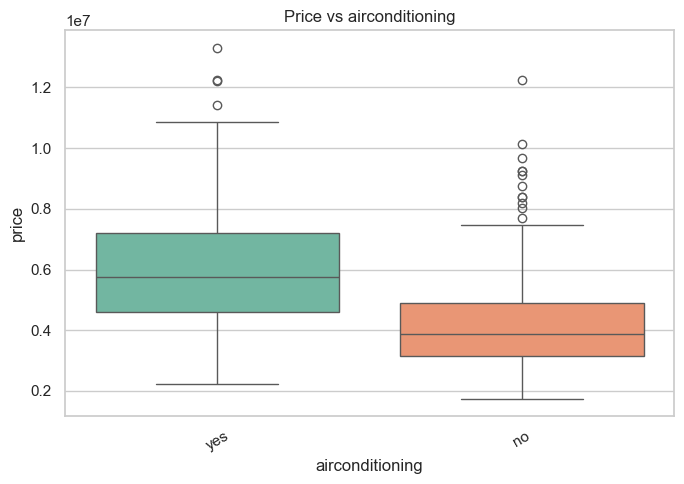

C:\Users\SadidGostaran.Co\AppData\Local\Temp\ipykernel_17556\1147570485.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="price", data=df, palette="Set2")


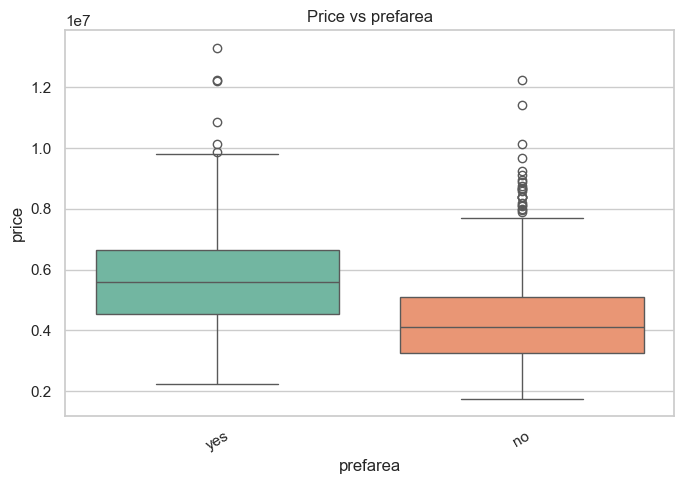

C:\Users\SadidGostaran.Co\AppData\Local\Temp\ipykernel_17556\1147570485.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="price", data=df, palette="Set2")


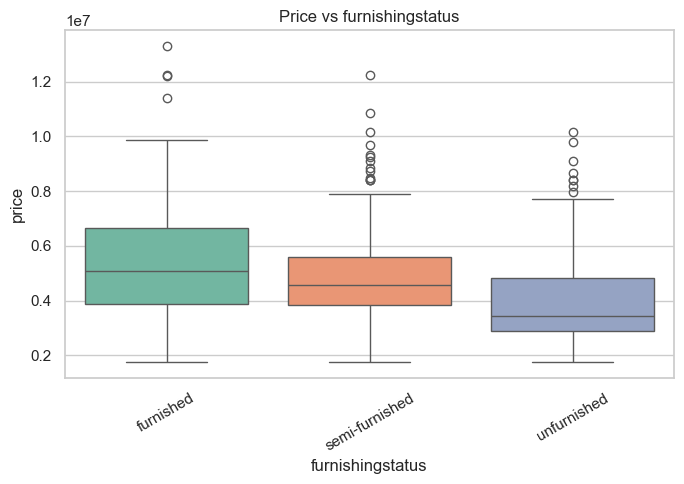


Mean price by mainroad:


mainroad
yes    4.991777e+06
no     3.398905e+06
Name: price, dtype: float64


Mean price by guestroom:


guestroom
yes    5.792897e+06
no     4.544546e+06
Name: price, dtype: float64


Mean price by basement:


...


Mean price by prefarea:


prefarea
yes    5.879046e+06
no     4.425299e+06
Name: price, dtype: float64


Mean price by furnishingstatus:


furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64

<Figure size 1000x600 with 0 Axes>

In [4]:
# =========================================================
# 01_eda.ipynb  |  Full EDA (Clean & Structured)
# =========================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# تنظیمات نمایش
pd.set_option("display.max_columns", 50)
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

# ---------------------------------------------------------
# 1) Load Data & Save Plots
# ---------------------------------------------------------
ROOT = Path().resolve().parent   # یک پوشه بالاتر از notebooks
data_path = ROOT / "data" / "raw" / "Housing.csv"
df = pd.read_csv(data_path)
save_dir = ROOT / "reports" / "figures"
save_dir.mkdir(parents=True, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)
print("Shape:", df.shape)
display(df.head())

# ---------------------------------------------------------
# 2) Basic Info & Summary Stats
# ---------------------------------------------------------
print("\n--- INFO ---")
df.info()

print("\n--- DESCRIBE (Numeric) ---")
display(df.describe())

# ---------------------------------------------------------
# 3) Missing Values
# ---------------------------------------------------------
print("\n--- Missing Values ---")
display(df.isna().sum())

# ---------------------------------------------------------
# 4) Price Distribution
# ---------------------------------------------------------
plt.figure(figsize=(10,5))
sns.histplot(df["price"], kde=True, bins=30, color="#2E86AB")
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "Price Distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6,6))
sns.boxplot(y=df["price"], color="#76B041")
plt.title("Price Boxplot")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "Price Boxplot.png"), dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 5) Correlation (Numeric Features)
# ---------------------------------------------------------
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "Correlation Heatmap (Numeric Features).png"), dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 6) Categorical Features Impact on Price
# ---------------------------------------------------------
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    plt.figure(figsize=(7,5))
    sns.boxplot(x=col, y="price", data=df, palette="Set2")
    plt.title(f"Price vs {col}")
    plt.xticks(rotation=30)
    plt.tight_layout()

    filename = f"price_vs_{col}.png"
    plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches="tight")
    plt.show()  # بهتر از show برای جلوگیری از مصرف حافظه


# ---------------------------------------------------------
# 7) Optional: Grouped Mean Price by Category
# ---------------------------------------------------------
for col in categorical_cols:
    print(f"\nMean price by {col}:")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "Mean price by {col}.png"), dpi=300, bbox_inches="tight")
    display(df.groupby(col)["price"].mean().sort_values(ascending=False))
